# SCIPP: Reading McStas h5 files

In [ ]:
import matplotlib.pyplot as plt
import scipp as sc
import numpy 
import os
import h5py 
import scipy
from scippneutron.conversion import graph
import matplotlib.pyplot as plt
import inspect
 

In [2]:
def take_component_data_names(l_component, l_data):
    l_res = []
    for component_name in l_component:
        hh = "_".join(component_name.split("_")[1:])
        for data_name in l_data:
            if data_name.startswith(hh):
                l_res.append((component_name, data_name))
    return l_res

def read_data_component_to_dict(component, data_component):
    component_type = get_component_type(component)
    if component_type == "PSD_monitor":
        d_out = read_psd_to_dict(component, data_component)
    elif component_type == "DivPos_monitor":
        d_out = read_divpos_to_dict(component, data_component)
    elif component_type == "TOF_monitor":
        d_out = read_tof_to_dict(component, data_component)
    else: 
        d_out = read_common_to_dict(component, data_component)
    return d_out


def read_psd_to_dict(component, data_component):
    d_out = read_common_to_dict(component, data_component)
    d_out["X_position"] = data_component["X_position__cm_"][()]
    d_out["Y_position"] = data_component["Y_position__cm_"][()]
    return d_out


def read_divpos_to_dict(component, data_component):
    d_out = read_common_to_dict(component, data_component)
    d_out["divergence"] = data_component["divergence__deg_"][()]
    d_out["pos"] = data_component["pos__m_"][()]
    return d_out
        

def read_tof_to_dict(component, data_component):
    d_out = read_common_to_dict(component, data_component)
    d_out["time_of_flight"] = data_component["Time_of_flight___gms_"][()]
    return d_out
        
def read_common_to_dict(component, data_component):
    values = data_component["data"][()]
    errors = data_component["errors"][()]
    ncount = data_component["ncount"][()]
    d_component = get_type_position_rotation_of_component(component)
    d_out = {
        "data": values,
        "errors": errors,
        "ncount": ncount,
    }
    d_out.update(d_component)
    return d_out

def get_component_type(component):
    component_type = component["Component_type"][()][0].decode("ascii")
    return component_type

def get_type_position_rotation_of_component(component):
    component_type = get_component_type(component)
    position = component["Position"][()]
    rotation = component["Rotation"][()]
    d_out = {
        "component_type": component_type,
        "position": position,
        "rotation": rotation,
    }
    return d_out
    


In [3]:
def plot_data(d_data):
    if d_data["component_type"] == "PSD_monitor":
        fig = display_psd(d_data)
    elif d_data["component_type"] == "TOF_monitor":
        fig = display_tof(d_data)
    elif d_data["component_type"] == "DivPos_monitor":
        fig = display_divpos(d_data)
    else:
        fig = get_figure_common(d_data)
    return fig

def get_figure_common(d_data):
    fig = plt.figure()
    ax = fig.add_axes((0,0,1,1))
    ncount = int(d_data["ncount"].sum())
    ax.set_title(d_data["component_name"] + f" at ({d_data['position'][0]:.3f} {d_data['position'][1]:.3f} {d_data['position'][2]:.3f})m Ncount {ncount:}")
    return fig

def display_psd(d_data):
    fig = get_figure_common(d_data)
    ax = fig.axes[0]
    np_x, np_y = d_data["X_position"], d_data["Y_position"]
    pos = ax.imshow(d_data["data"].transpose(), origin="lower", extent=(np_x.min(), np_x.max(), np_y.min(), np_y.max()),vmin=0, vmax=1e7)
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel("X position (cm)")
    ax.set_ylabel("Y position (cm)")
    return fig

def display_tof(d_data):
    fig = get_figure_common(d_data)
    ax = fig.axes[0]
    np_x, np_y = d_data["time_of_flight"], d_data["data"]
    ax.plot(np_x, np_y,"ko")
    ax.plot(np_x, np_y,"k-", alpha=0.3)
    ax.set_xlabel("Time of Flight (micro seconds)")
    ax.set_ylabel("Intensity (arb. units)")
    return fig

def display_divpos(d_data):
    fig = get_figure_common(d_data)
    ax = fig.axes[0]
    np_x, np_y = d_data["pos"], d_data["divergence"]
    pos = ax.imshow(d_data["data"].transpose(), origin="lower", extent=(np_x.min(), np_x.max(), np_y.min(), np_y.max()), aspect="auto")
    fig.colorbar(pos, ax=ax)
    ax.set_xlabel("Position (cm)")
    ax.set_ylabel("Divergence (deg.)")
    return fig

In [4]:
def read_h5_to_dict(f_nexus):
    d_out = {}
    delta_L_deafault = sc.scalar(0., unit='m')
    delta_t_default = sc.scalar(3., unit='ms').to(unit="s", copy=False)
    with h5py.File(f_nexus) as fid:
        components = fid["entry1"]["instrument"]["components"] 
        l_key_sample = [hh for hh in components.keys() if "_sampleMantid" in hh]
        l_key_source = [hh for hh in components.keys() if "_sourceMantid" in hh]
        l_key_detector = [hh for hh in components.keys() if "_nD_Mantid_" in hh]

        l_components = components.keys()

        sample = components[l_key_sample[0]]
        sample_position = sample["Position"][()]

        detector = components[l_key_detector[0]]
        detector_position = detector["Position"][()]
        detector_rotation = detector["Rotation"][()]
        detector_radius = float(detector["Geometry"].attrs["radius"])

        data = fid["entry1"]["data"] # 
        l_data = data.keys()
        l_component_data_names = take_component_data_names(l_components, l_data)
        for component_name, data_name in l_component_data_names:
            component = components[component_name]
            data_component = data[data_name]
        
            d_out[data_name] = read_data_component_to_dict(component, data_component)
            d_out[data_name]["component_name"] = component_name
        d_components = {}
        for component_name in l_components:
            component = components[component_name]
            d_component = get_type_position_rotation_of_component(component)
            component_name_short = "_".join(component_name.split("_")[1:])
            d_components[component_name_short] = d_component
        d_out["components"] = d_components

        simulation_param = fid["entry1"]["simulation"]["Param"]
        sample_omega = float(simulation_param["sample_rotation_y"][()][0].decode("ascii"))
        neutron_up = simulation_param["isFlip"][()]
        
        if "bank00_events_dat_list_p_th_y_n_id_t" in l_data:
            data_events = data["bank00_events_dat_list_p_th_y_n_id_t"]["events"][()]
            da = sc.DataArray(
                data=sc.array(
                    dims=['event'], values=data_events[:, 0], variances=(data_events[:, 0]**2)
                ),
            coords={
                'detector_radius': sc.scalar(detector_radius, unit='m'),
                'delta_L': delta_L_deafault,
                'delta_t': delta_t_default,
                'source_position': sc.vector(value=d_components['arm_w6']["position"], unit='m'),
                'tp_position': sc.vector(value=d_components["arm_egs2"]["position"],unit="m"),
                'ideal_sample_position': sc.vector(sample_position, unit='m'),
                'sample_offset': sc.vector([0., 0., 0.], unit='m'),
                'detector_position': sc.vector(detector_position, unit='m'),
                'detector_pixel_gamma_local': sc.array(dims=['event'], values=data_events[:,1], unit='deg').to(unit="rad", copy=False),
                'detector_pixel_vertical_local': sc.array(dims=['event'], values=data_events[:,2], unit='m'),
                'toa': sc.array(dims=['event'], values=data_events[:, 5], unit='s'),
                'sample_omega': sc.scalar(sample_omega, unit='deg.').to(unit="rad", copy=False),
                'sample_chi': sc.scalar(0., unit='deg.').to(unit="rad", copy=False),
                'sample_phi': sc.scalar(0., unit='deg.').to(unit="rad", copy=False),
            }
            )
            d_out["data_event"] = da
        if "tof_egs2_1_plot" in d_out.keys(): # cave monitor
            data_monitor = d_out["tof_egs2_1_plot"]
            da = sc.DataArray(
                data=sc.array(
                    dims=['counts'], values=data_monitor['data'], variances=(data_monitor['errors']**2)
                ),
            coords={
                'source_position': sc.vector(value=d_components['arm_w6']["position"], unit='m'),
                'tp_position': sc.vector(value=d_components["arm_egs2"]["position"],unit="m"),
                'cave_monitor_position': sc.vector(value=d_components["tof_egs2_1"]["position"],unit="m"),
                'delta_L': delta_L_deafault,
                'delta_t': delta_t_default,
                'toa': sc.array(dims=['counts'], values=data_monitor["time_of_flight"], unit='micros').to(unit="s", copy=False),
            }
            )
            d_out["data_cave_monitor"] = da           
    return d_out

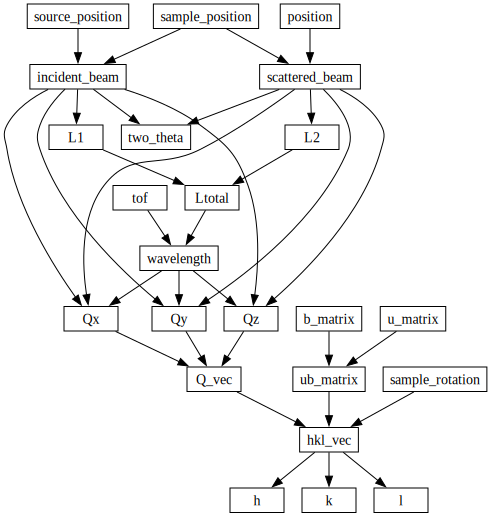

In [5]:
scipp_graph = {**graph.beamline.beamline(scatter=True), **graph.tof.elastic_hkl(start='tof')}
sc.show_graph(scipp_graph, simplified=True)

In [6]:
def get_sc_rotation_matrix(r_matrix):
    quternion_r_matrix = scipy.spatial.transform.Rotation.from_matrix(r_matrix).as_quat()
    r_out = sc.spatial.rotation(value=quternion_r_matrix / numpy.linalg.norm(quternion_r_matrix))
    return r_out 
    
def calc_incident_beam_magic(source_position, tp_position, sample_position):
    tp = tp_position.to(unit='m', copy=False)
    v1 = sample_position.to(unit='m', copy=False) - tp
    v2 = tp - source_position.to(unit='m', copy=False)
    e1 = v1/sc.norm(v1)
    incident_beam = v1 + e1 * sc.norm(v2)
    return incident_beam

def calc_position(detector_position, detector_event_position_local):
    position = detector_position.to(unit='m', copy=False) + detector_event_position_local.to(unit='m', copy=False)
    return position

def calc_detector_event_position_local(detector_pixel_gamma_local, detector_pixel_vertical_local, detector_radius):
    dr = detector_radius.to(unit='m', copy=False)
    dy = detector_pixel_vertical_local.to(unit='m', copy=False)
    dx = dr * sc.sin(detector_pixel_gamma_local.to(unit="deg", copy=False))
    dz = dr * sc.cos(detector_pixel_gamma_local.to(unit="deg", copy=False))
    detector_event_position_local = sc.spatial.as_vectors(dx, dy, dz)
    return detector_event_position_local

def calc_tof(toa, delta_t=sc.scalar(value=3, unit="ms")):
    tof = toa.to(unit='s', copy=False) - delta_t.to(unit='s', copy=False)
    return tof

def calc_Ltotal(L1, L2, delta_L=sc.scalar(value=0, unit="m")):
    Ltotal = L1.to(unit='m', copy=False) + L2.to(unit='m', copy=False) - delta_L.to(unit='m', copy=False)
    return Ltotal

def calc_sample_rotation(sample_omega, sample_chi, sample_phi):
    zero_o = sc.sin(sc.zeros_like(sample_omega))
    one_o = sc.cos(sc.zeros_like(sample_omega))
    m_omega = [
        [sc.cos(sample_omega), zero_o, sc.sin(sample_omega)],
        [zero_o, one_o, zero_o],
        [-sc.sin(sample_omega), zero_o, sc.cos(sample_omega)],
    ]
    zero_c = sc.sin(sc.zeros_like(sample_chi))
    one_c = sc.cos(sc.zeros_like(sample_chi))
    m_chi = [
        [sc.cos(sample_chi), -sc.sin(sample_chi), zero_c],
        [sc.sin(sample_chi), sc.cos(sample_chi), zero_c],
        [zero_c, zero_c, one_c],
    ]

    zero_p = sc.sin(sc.zeros_like(sample_phi))
    one_p = sc.cos(sc.zeros_like(sample_phi))
    m_phi = [
        [sc.cos(sample_phi), zero_p, sc.sin(sample_phi)],
        [zero_p, one_p, zero_p],
        [-sc.sin(sample_phi), zero_p, sc.cos(sample_phi)],
    ]
    rm_o = get_sc_rotation_matrix(m_omega)
    rm_c = get_sc_rotation_matrix(m_chi)
    rm_p = get_sc_rotation_matrix(m_phi)
    sample_rotation = rm_o * rm_c * rm_p
    return sample_rotation

def calc_orientation_matrix(euler_alpha, euler_beta, euler_gamma, ):
    ca, cb, cg = sc.cos(euler_alpha), sc.cos(euler_beta), sc.cos(euler_gamma)
    sa, sb, sg = sc.sin(euler_alpha), sc.sin(euler_beta), sc.sin(euler_gamma)
    m_m = [
        [ca*cb, ca*sb*sg-sa*cg, ca*sb*cg+sa*sg],
        [sa*cb, sa*sb*sg+ca*cg, sa*sb*cg-ca*sg],
        [-sb, cb*sg, cb*cg],
    ]
    orientation_matrix = get_sc_rotation_matrix(m_m)
    return orientation_matrix

def _calc_cell_phi(cell_alpha, cell_beta, cell_gamma):
    ca, cb, cg = sc.cos(cell_alpha), sc.cos(cell_beta), sc.cos(cell_gamma)
    cell_phi = sc.sqrt(1. - ca*ca - cb*cb - cg*cg + 2 * ca * cb * cg)
    return cell_phi

def calc_cell_volume(cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma):
    cell_phi = _calc_cell_phi(cell_alpha, cell_beta, cell_gamma)
    cell_volume = cell_a.to(unit="angstrom") * cell_b.to(unit="angstrom") * cell_c.to(unit="angstrom") * cell_phi
    return cell_volume

def calc_b_matrix(cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma):
    cell_phi = _calc_cell_phi(cell_alpha, cell_beta, cell_gamma)
    a, b, c = cell_a.to(unit="angstrom").value, cell_b.to(unit="angstrom").value, cell_c.to(unit="angstrom").value
    b_11 = sc.sin(cell_alpha)/(a*cell_phi)
    b_12 = (sc.cos(cell_alpha)*sc.cos(cell_beta)-sc.cos(cell_gamma))/(b*cell_phi*sc.sin(cell_alpha))
    b_13 = (sc.cos(cell_alpha)*sc.cos(cell_gamma)-sc.cos(cell_beta))/(c*cell_phi*sc.sin(cell_alpha))
    b_22 = 1/(b*sc.sin(cell_alpha))
    b_23 = -sc.cos(cell_alpha)/(c*sc.sin(cell_alpha))
    b_33 = 1/c
    zero = 0.
    b_matrix = sc.spatial.linear_transform(
        value=[
            [b_11, b_12, b_13],
            [zero, b_22, b_23],
            [zero, zero, b_33],
        ],
        unit='1/angstrom',
    )
    return b_matrix

def calc_h_reduced(h):
    h_reduced = h%1
    return h_reduced

def calc_k_reduced(k):
    k_reduced = k%1
    return k_reduced

def calc_l_reduced(l):
    l_reduced = l%1
    return l_reduced

def Q_vec_rot_from_elastic_Q_vec(*, Q_vec: sc.Variable, sample_rotation: sc.Variable) -> sc.Variable:
    return (sc.spatial.inv(sample_rotation) * Q_vec)

def hkl_vec_from_elastic_Q_vec_rot(*, Q_vec_rot: sc.Variable, ub_matrix: sc.Variable) -> sc.Variable:
    return (sc.spatial.inv(ub_matrix) * Q_vec_rot) / (2 * numpy.pi)

def Q_vec_rot_from_elastic_hkl_vec(*, hkl_vec: sc.Variable, ub_matrix: sc.Variable) -> sc.Variable:
    return (ub_matrix * hkl_vec * 2 * numpy.pi)



def calc_sample_position(ideal_sample_position, sample_offset):
    sample_position = ideal_sample_position.to(unit='m', copy=False) + sample_offset.to(unit='m', copy=False)
    return sample_position

graph_qvec = {
    "incident_beam": calc_incident_beam_magic,
    "position": calc_position,
    "detector_event_position_local": calc_detector_event_position_local,
    "tof": calc_tof,
    "Ltotal": calc_Ltotal,
    "sample_rotation": calc_sample_rotation,
    "Q_vec_rot": Q_vec_rot_from_elastic_Q_vec,
    "L1": scipp_graph["L1"],
    "L2": scipp_graph["L2"],
    "scattered_beam": scipp_graph["scattered_beam"],
    "Q_vec": scipp_graph["Q_vec"],
    "wavelength": scipp_graph["wavelength"],
    ("Qx","Qy","Qz"): scipp_graph[("Qx","Qy","Qz")],
    "sample_position": calc_sample_position,
}
graph_hkl = {

    "cell_volume": calc_cell_volume,
    "b_matrix": calc_b_matrix,
    "u_matrix": calc_orientation_matrix,
    "h_reduced": calc_h_reduced,
    "k_reduced": calc_k_reduced,
    "l_reduced": calc_l_reduced,
    "hkl_vec": hkl_vec_from_elastic_Q_vec_rot,
    "ub_matrix": scipp_graph["ub_matrix"],
    ("h","k","l"): scipp_graph[("h","k","l")],
}

graph_hkl_inv = {
    "Q_vec_rot": Q_vec_rot_from_elastic_hkl_vec,
    "b_matrix": graph_hkl["b_matrix"],
    "u_matrix": graph_hkl["u_matrix"],
    "ub_matrix": graph_hkl["ub_matrix"],
}

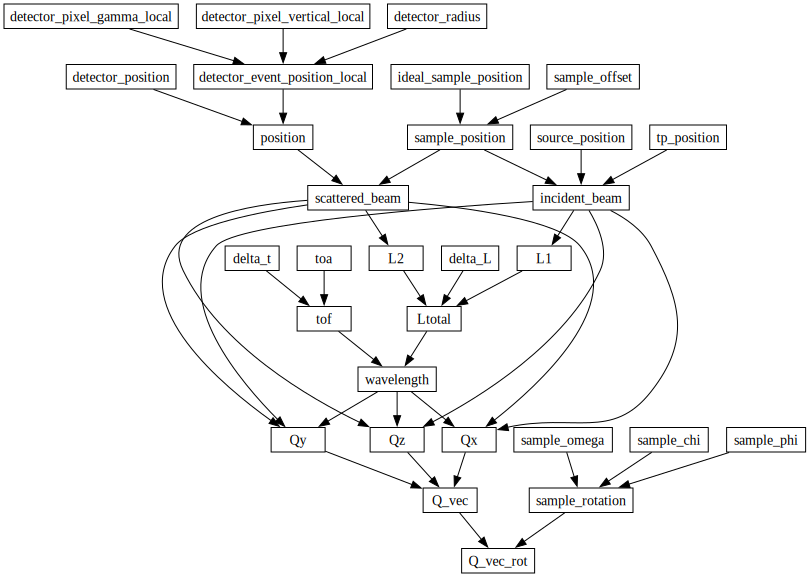

In [7]:
sc.show_graph(graph_qvec, simplified=True)

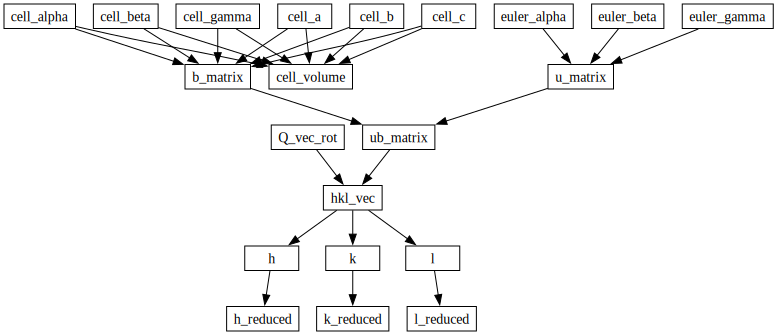

In [8]:
sc.show_graph(graph_hkl, simplified=True)

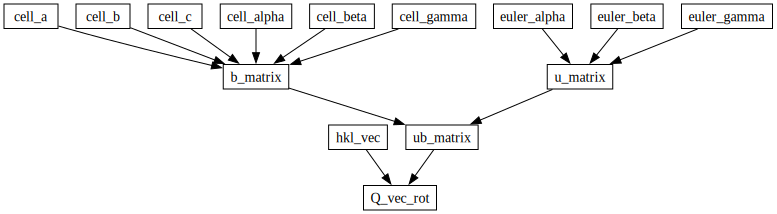

In [9]:
sc.show_graph(graph_hkl_inv, simplified=True)

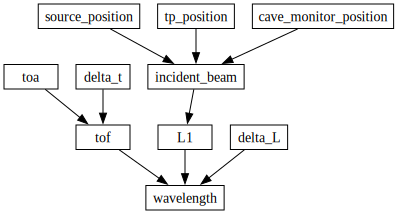

In [10]:
def calc_incident_beam_cave_monitor(source_position, tp_position, cave_monitor_position):
    incident_beam = graph_qvec["incident_beam"](source_position, tp_position, cave_monitor_position)
    return incident_beam

def calc_wavelength(L1, delta_L, tof):
    Ltotal = L1.to(unit='m', copy=False) - delta_L.to(unit='m', copy=False)
    wavelength = graph_qvec["wavelength"](Ltotal=Ltotal, tof=tof)
    return wavelength

graph_cave_monitor = {
    "tof": graph_qvec["tof"],
    "L1": graph_qvec["L1"],
    "incident_beam": calc_incident_beam_cave_monitor,
    "wavelength": calc_wavelength,
}
sc.show_graph(graph_cave_monitor, simplified=True)

# Preprocessing

## Load Event Data

In [11]:
f_nexus = r"/Users/iuriikibalin/Documents/files/ESS/McStas/mcstasscript_magic/run_folder_27/mccode.h5"
f_nexus = r"/Users/iuriikibalin/Documents/files/ESS/McStas/scipp_magic/mcstas_simulations/mccode.h5"
d_out = read_h5_to_dict(f_nexus)
d_out.keys()

dict_keys(['tof_chop_1_plot', 'tof_w6_1_plot', 'tof_egs2_1_plot', 'psd_sample_pos_1_plot', 'divpos_sample_pos_1_plot', 'components', 'data_event', 'data_cave_monitor'])

In [12]:
data_cave_monitor = d_out["data_cave_monitor"]
data_event = d_out["data_event"]

In [13]:
"""
fig = plot_data(d_out["tof_chop_1_plot"])
fig = plot_data(d_out["tof_w6_1_plot"])
fig = plot_data(d_out["tof_egs2_1_plot"])
fig = plot_data(d_out["psd_sample_pos_1_plot"])
fig = plot_data(d_out["divpos_sample_pos_1_plot"])
"""
data_event

<scipp.DataArray>
Dimensions: Sizes[event:2015340, ]
Coordinates:
* delta_L                   float64              [m]  ()  0
* delta_t                   float64              [s]  ()  0.003
* detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
* detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
* detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
* detector_radius           float64              [m]  ()  1
* ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
* sample_chi                float64            [rad]  ()  0
* sample_offset             vector3              [m]  ()  (0, 0, 0)
* sample_omega              float64            [rad]  ()  0
* sample_phi                float64            [rad]  ()  0
* source_position           vector3              [m]  ()  (-0.034, 0, 0)
* toa                       float64              [s]  (event)  [0.0690874, 0.0562372, ..., 0.0565717, 0.0565965]
* tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
Data:
                            float64  [dimensionless]  (event)  [0.0172735, 0.00127292, ..., 9.18242e-11, 1.25802e-13]  [0.000298374, 1.62032e-06, ..., 8.43169e-21, 1.58262e-26]

In [16]:
data_cave_monitor

<scipp.DataArray>
Dimensions: Sizes[counts:101, ]
Coordinates:
* cave_monitor_position     vector3              [m]  ()  (-0.034, -0.674198, 152.955)
* delta_L                   float64              [m]  ()  0
* delta_t                   float64              [s]  ()  0.003
* source_position           vector3              [m]  ()  (-0.034, 0, 0)
* toa                       float64              [s]  (counts)  [0.000693069, 0.00207921, ..., 0.137921, 0.139307]
* tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
Data:
                            float64  [dimensionless]  (counts)  [0, 0, ..., 0, 0]  [0, 0, ..., 0, 0]

## Transform to Q-space

In [17]:
da_q_event = data_event.transform_coords(("Q_vec_rot",), graph=graph_qvec)
da_q_event

<scipp.DataArray>
Dimensions: Sizes[event:2015340, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00573, ..., 1.0211, 1.09208]
  Ltotal                    float64              [m]  (event)  [155.5, 155.506, ..., 155.521, 155.592]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
  Qx                        float64           [1/Å]  (event)  [-3.73697, -4.61269, ..., -4.13153, -4.13061]
  Qy                        float64           [1/Å]  (event)  [0.00973955, 0.494463, ..., 0.932518, 1.85303]
  Qz                        float64           [1/Å]  (event)  [3.71059, 4.67838, ..., 2.78865, 3.7371]
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965964, -0.78139, 154.489), ..., (0.880968, -0.880713, 154.901), (0.944357, -1.1131, 154.704)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  toa                       float64              [s]  (event)  [0.0690874, 0.0562372, ..., 0.0565717, 0.0565965]
  tof                       float64              [s]  (event)  [0.0660874, 0.0532372, ..., 0.0535717, 0.0535965]
  tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
  wavelength                float64             [Å]  (event)  [1.68131, 1.35434, ..., 1.36272, 1.36273]
Data:
                            float64  [dimensionless]  (event)  [0.0172735, 0.00127292, ..., 9.18242e-11, 1.25802e-13]  [0.000298374, 1.62032e-06, ..., 8.43169e-21, 1.58262e-26]

## Calibration: normalization per incident spectra estimated by cave monitor

In [18]:
da_cm = data_cave_monitor.transform_coords(("wavelength",), graph=graph_cave_monitor)
da_cm

<scipp.DataArray>
Dimensions: Sizes[counts:101, ]
Coordinates:
  L1                        float64              [m]  ()  152.958
  cave_monitor_position     vector3              [m]  ()  (-0.034, -0.674198, 152.955)
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  incident_beam             vector3              [m]  ()  (0, 0, 152.958)
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  toa                       float64              [s]  (counts)  [0.000693069, 0.00207921, ..., 0.137921, 0.139307]
  tof                       float64              [s]  (counts)  [-0.00230693, -0.000920792, ..., 0.134921, 0.136307]
  tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
* wavelength                float64             [Å]  (counts)  [-0.0596653, -0.0238149, ..., 3.48953, 3.52538]
Data:
                            float64  [dimensionless]  (counts)  [0, 0, ..., 0, 0]  [0, 0, ..., 0, 0]

In [19]:
def normalize_per_cave_monitor(da_q_event, da_cm, factor=0.1):
    da_cm.masks["counts"] = sc.logical_not(da_cm.data > factor*da_cm.data.max())
    cm_wavelength = da_cm.coords['wavelength'][sc.logical_not(da_cm.masks["counts"])]
    cm_weight = da_cm.data[sc.logical_not(da_cm.masks["counts"])]
    cm_weight = cm_weight/cm_weight.max().values
    cm_wavelength_min = cm_wavelength.min()
    cm_wavelength_max = cm_wavelength.max()

    flag = sc.logical_and(da_q_event.coords['wavelength'] >  cm_wavelength_min, da_q_event.coords['wavelength'] < cm_wavelength_max)
    da_q_event_reduced = da_q_event[flag]
    coeff = numpy.interp(da_q_event_reduced.coords['wavelength'].values, cm_wavelength.values, cm_weight.values)
    da_q_event_reduced.data  = da_q_event_reduced.data /sc.array(dims=("event",), values=coeff, unit=da_q_event_reduced.data.unit)
    return da_q_event_reduced

In [20]:
da_q_event_reduced = normalize_per_cave_monitor(da_q_event, da_cm, factor=0.1)
da_q_event_reduced

<scipp.DataArray>
Dimensions: Sizes[event:1744654, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00573, ..., 1.0211, 1.09208]
  Ltotal                    float64              [m]  (event)  [155.5, 155.506, ..., 155.521, 155.592]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
  Qx                        float64           [1/Å]  (event)  [-3.73697, -4.61269, ..., -4.13153, -4.13061]
  Qy                        float64           [1/Å]  (event)  [0.00973955, 0.494463, ..., 0.932518, 1.85303]
  Qz                        float64           [1/Å]  (event)  [3.71059, 4.67838, ..., 2.78865, 3.7371]
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965964, -0.78139, 154.489), ..., (0.880968, -0.880713, 154.901), (0.944357, -1.1131, 154.704)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  toa                       float64              [s]  (event)  [0.0690874, 0.0562372, ..., 0.0565717, 0.0565965]
  tof                       float64              [s]  (event)  [0.0660874, 0.0532372, ..., 0.0535717, 0.0535965]
  tp_position               vector3              [m]  ()  (-0.034, -0.674198, 83.8973)
  wavelength                float64             [Å]  (event)  [1.68131, 1.35434, ..., 1.36272, 1.36273]
Data:
                            float64  [dimensionless]  (event)  [0.0672322, 0.00186339, ..., 1.37066e-10, 1.8779e-13]  [0.00452017, 3.47223e-06, ..., 1.87872e-20, 3.5265e-26]

# Peak finding

In [21]:
from scipy.spatial import cKDTree

def adaptive_bandwidth(q):
    # Replace with your MAGiC/ESS resolution model
    Q = numpy.linalg.norm(q)
    return 0.01 + 0.02 * Q


class MeanShiftNeighborSearch:
    def __init__(self, q_events):
        self.q_events = numpy.asarray(q_events)
        self.tree = cKDTree(self.q_events)

    def neighbors_within(self, x, radius):
        idx = self.tree.query_ball_point(x, radius)
        return numpy.asarray(idx, dtype=int)


def mean_shift_single_accel(
    q_events,
    weights,
    start,
    max_iter=200,
    tol=1e-6,
    radius_factor=3.0,
    neighbor_search=None,
):
    """
    One adaptive mean-shift run using KD-tree neighbor search.
    """
    if neighbor_search is None:
        neighbor_search = MeanShiftNeighborSearch(q_events)

    x = start.copy()
    for _ in range(max_iter):
        h = adaptive_bandwidth(x)
        radius = radius_factor * h

        idx = neighbor_search.neighbors_within(x, radius)
        if idx.size == 0:
            break

        q_loc = q_events[idx]
        w_loc = weights[idx]

        diff = q_loc - x
        dist2 = numpy.sum(diff**2, axis=1)

        k = numpy.exp(-dist2 / (2 * h * h))
        w = w_loc * k
        denom = numpy.sum(w)
        if denom == 0:
            break

        x_new = numpy.sum(q_loc * w[:, None], axis=0) / denom
        if numpy.linalg.norm(x_new - x) < tol:
            return x_new

        x = x_new

    return x
def _cluster_modes(modes, merge_radius):
    clusters = []
    for m in modes:
        placed = False
        for c in clusters:
            if numpy.linalg.norm(m - c) < merge_radius:
                c[:] = 0.5 * (c + m)
                placed = True
                break
        if not placed:
            clusters.append(m.copy())
    return numpy.array(clusters)


def _compute_peak_intensity(q_events, weights, peak, radius, neighbor_search):
    idx = neighbor_search.neighbors_within(peak, radius)
    if idx.size == 0:
        return 0.0
    return numpy.sum(weights[idx])


def find_multiple_peaks_accel(
    events_coords,
    events_weight=None,
    # max_peaks=10,
    merge_radius=0.05,
    basin_radius=0.1,
    max_seeds=5000,
    random_state=None,
    radius_factor=3.0,
):
    """
    Multi-peak adaptive mean-shift with KD-tree acceleration.
    """
    q_events = events_coords.values


    q_events = numpy.asarray(q_events)
    N, d = q_events.shape

    if events_weight is None:
        weights = numpy.ones(N, dtype=float)
    else:
        weights = numpy.asarray(events_weight.values, dtype=float)


    rng = numpy.random.default_rng(random_state)
    if N > max_seeds:
        idx_seeds = rng.choice(N, size=max_seeds, replace=False)
    else:
        idx_seeds = numpy.arange(N)

    neighbor_search = MeanShiftNeighborSearch(q_events)

    modes = []
    for i in idx_seeds:
        m = mean_shift_single_accel(
            q_events,
            weights,
            start=q_events[i],
            neighbor_search=neighbor_search,
            radius_factor=radius_factor,
        )
        modes.append(m)
    modes = numpy.array(modes)

    unique_peaks = _cluster_modes(modes, merge_radius)

    intensities = numpy.array([
        _compute_peak_intensity(
            q_events, weights, p, basin_radius, neighbor_search
        )
        for p in unique_peaks
    ])

    idx = numpy.argsort(intensities)[::-1]#[:max_peaks]
    peaks_q = sc.vectors(dims=['peaks'], values=unique_peaks[idx], unit=events_coords.unit)
    if events_weight is None:
        peaks_intensity =sc.array(dims=['peaks'], values=intensities[idx], unit='counts')
    else:
        peaks_intensity =sc.array(dims=['peaks'], values=intensities[idx], unit=events_weight.unit)


    da = sc.DataArray(
                data=sc.array(
                    dims=['peaks'], values=intensities[idx]
                    ),
            coords={
                'Q_vec_rot': peaks_q,
            }
            )
    return da

In [22]:
da_peaks = find_multiple_peaks_accel(
    events_coords=da_q_event_reduced.coords['Q_vec_rot'],
    events_weight=da_q_event_reduced.data,
    merge_radius=0.05,
    basin_radius=0.1,
    max_seeds=5000,
    random_state=None,
    radius_factor=3.0,
)
da_peaks

<scipp.DataArray>
Dimensions: Sizes[peaks:371, ]
Coordinates:
* Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-8.75418, -0.06661, 14.0495), (-8.61684, -0.736409, 8.78928)]
Data:
                            float64  [dimensionless]  (peaks)  [374.518, 319.856, ..., 0, 0]

# Indexing
## UB matrix based on the strong peaks using provided unit cell parameters

In [23]:
import numpy as np
import scipy.optimize

def get_euleur_opt(
        cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
        Q_vec_rot, weight,
        euler_alpha, euler_beta, euler_gamma, graph_hkl=graph_hkl,
        relfine_unit_cell=False,singony='triclinic'):
    """
    Joint refinement of UB matrix and unknown hkl values.

    Parameters
    ----------
    B : (3,3) array
        Reciprocal lattice matrix.
    q_list : (N,3) array
        Measured Q vectors.
    hkl_init : (N,3) array or None
        Initial guess for hkl. If None, use fractional guess from B^-1 Q.

    Returns
    -------
    UB : (3,3) array
        Refined UB matrix.
    hkl : (N,3) array
        Refined fractional hkl values.
    """
    np_weight = np.asarray(weight.values)
    np_weight = np_weight / np.max(np_weight)

    ea_rad = euler_alpha.to(unit="rad", copy=False).value
    eb_rad = euler_beta.to(unit="rad", copy=False).value
    eg_rad = euler_gamma.to(unit="rad", copy=False).value


    h90 = sc.scalar(90., unit="deg")
    h120 = sc.scalar(120., unit="deg")

    def calc_b_matrix_by_x(x_cell):
        if singony.startswith('c'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,ha,ha,h90,h90,h90)
        elif singony.startswith('h'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hc = sc.scalar(x_cell[1], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,ha,hc,h90,h90,h120)
        elif singony.startswith('te'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hc = sc.scalar(x_cell[1], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,ha,hc,h90,h90,h90)
        elif singony.startswith('o'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hb = sc.scalar(x_cell[1], unit="angstrom")
            hc = sc.scalar(x_cell[2], unit="angstrom")
            sc_b_matrix = graph_hkl['b_matrix'](ha,hb,hc,h90,h90,h90)
        elif singony.startswith('m'):
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hb = sc.scalar(x_cell[1], unit="angstrom")
            hc = sc.scalar(x_cell[2], unit="angstrom")
            hbe = sc.scalar(x_cell[3], unit="deg")
            sc_b_matrix = graph_hkl['b_matrix'](ha,hb,hc,h90,hbe,h90)
        else:
            ha = sc.scalar(x_cell[0], unit="angstrom")
            hb = sc.scalar(x_cell[1], unit="angstrom")
            hc = sc.scalar(x_cell[2], unit="angstrom")
            hal = sc.scalar(x_cell[3], unit="deg")
            hbe = sc.scalar(x_cell[4], unit="deg")
            hga = sc.scalar(x_cell[5], unit="deg")
            sc_b_matrix = graph_hkl['b_matrix'](ha,hb,hc,hal,hbe,hga)
        return sc_b_matrix

    cell_a_ang = cell_a.to(unit="angstrom", copy=False).value
    cell_b_ang = cell_b.to(unit="angstrom", copy=False).value
    cell_c_ang = cell_c.to(unit="angstrom", copy=False).value
    cell_alpha_deg = cell_alpha.to(unit="deg", copy=False).value
    cell_beta_deg = cell_beta.to(unit="deg", copy=False).value
    cell_gamma_deg = cell_gamma.to(unit="deg", copy=False).value

    if not relfine_unit_cell:
        sc_b_matrix = graph_hkl['b_matrix'](cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma)
        x0 = [ea_rad,eb_rad,eg_rad]
    elif singony.startswith('c'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,]
    elif singony.startswith('h') or singony.startswith('te'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,cell_c_ang]
    elif singony.startswith('o'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,cell_b_ang, cell_c_ang]
    elif singony.startswith('m'):
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang,cell_b_ang, cell_c_ang, cell_beta_deg]
    else:
        x0 = [ea_rad,eb_rad,eg_rad, cell_a_ang, cell_b_ang, cell_c_ang, cell_alpha_deg, cell_beta_deg, cell_gamma_deg]
        

    def calc_chi_sq(x):
        euleur_angles = x[:3]
        if relfine_unit_cell:
            sc_b_matrix = calc_b_matrix_by_x(x[3:])
        else:
            sc_b_matrix = graph_hkl['b_matrix'](cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma)
        sc_u = graph_hkl_inv["u_matrix"](
            sc.scalar(euleur_angles[0], unit="rad"),
            sc.scalar(euleur_angles[1], unit="rad"),
            sc.scalar(euleur_angles[2], unit="rad"),
            )
        sc_UB = graph_hkl["ub_matrix"](u_matrix=sc_u, b_matrix=sc_b_matrix)
        sc_hkl_int = graph_hkl["hkl_vec"](ub_matrix=sc_UB, Q_vec_rot=Q_vec_rot)
        sc_hkl_int.values = numpy.round(sc_hkl_int.values,0) 
        Q_vec_rot_ref = graph_hkl_inv["Q_vec_rot"](ub_matrix=sc_UB, hkl_vec=sc_hkl_int)
        Q_vec_rot_diff = Q_vec_rot_ref - Q_vec_rot
        chi_sq = (numpy.square(Q_vec_rot_diff.values)* numpy.expand_dims(np_weight, axis=1)).sum()
        return chi_sq


    res = scipy.optimize.minimize(calc_chi_sq, x0, method='Nelder-Mead')
    ea_opt = res.x[:3]
    if relfine_unit_cell:
        sc_b_matrix =calc_b_matrix_by_x(res.x[3:])
    else:
        ea_opt = res.x[:3]
    return (sc.scalar(ea_opt[0], unit="rad"), sc.scalar(ea_opt[1], unit="rad"), sc.scalar(ea_opt[2], unit="rad")), sc_b_matrix, res.fun

In [84]:
# Given by User
cell_a = sc.scalar(14.04078, unit="angstrom")
cell_b = sc.scalar(14.04078, unit="angstrom")
cell_c = sc.scalar(14.04078, unit="angstrom")
cell_alpha = sc.scalar(90., unit="deg")
cell_beta = sc.scalar(90., unit="deg")
cell_gamma = sc.scalar(90., unit="deg")

# First estimation
euler_alpha = sc.scalar(2., unit="deg")
euler_beta = sc.scalar(1., unit="deg")
euler_gamma = sc.scalar(0., unit="deg")

# Only strong peaks used for refinement
factor = 0.1
da_peaks_strong = da_peaks[da_peaks.data > factor* da_peaks.data.max()]
da_peaks_strong


<scipp.DataArray>
Dimensions: Sizes[peaks:78, ]
Coordinates:
  Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-5.11614, -0.464836, 3.25748), (-5.57221, 6.59251e-05, 5.58331)]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0737479, -4.51576e-18, -4.51576e-18), , (0, 0.0737479, -4.51576e-18), , (0, 0, 0.0737479), )
  euler_alpha               float64            [rad]  ()  -0.00432641
  euler_beta                float64            [rad]  ()  -0.000486802
  euler_gamma               float64            [rad]  ()  0.00466673
* h                         float64  [dimensionless]  (peaks)  [-7.98741, -7.99428, ..., -11.0333, -12.0194]
  hkl_vec                   vector3  [dimensionless]  (peaks)  [(-7.98741, 0.00305017, 7.99713), (-7.99428, 0.998153, 6.99493), ..., (-11.0333, -1.01808, 7.04014), (-12.0194, 0.00437441, 12.0553)]
* k                         float64  [dimensionless]  (peaks)  [0.00305017, 0.998153, ..., -1.01808, 0.00437441]
* l                         float64  [dimensionless]  (peaks)  [7.99713, 6.99493, ..., 7.04014, 12.0553]
  u_matrix                rotation3  [dimensionless]  ()  (0.999995+0.00233283i-0.000248447j-0.00216263k)
  ub_matrix               linear_transform3           [1/Å]  ()  ((0.0737472, 0.000318892, -3.73889e-05), , (-0.000319063, 0.0737464, -0.000344002), , (3.59007e-05, 0.00034416, 0.0737471), )
Data:
                            float64  [dimensionless]  (peaks)  [374.518, 319.856, ..., 41.2101, 38.5483]

In [87]:
ea_opt, sc_b_matrix, chi_sq = get_euleur_opt(
    cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
    da_peaks_strong.coords["Q_vec_rot"], da_peaks_strong.data,
    euler_alpha, euler_beta, euler_gamma, graph_hkl=graph_hkl,
    relfine_unit_cell=True,singony='cubic')


In [88]:
print(f"Optimized Euler angles (deg): {ea_opt[0].to(unit='deg').value:.2f} {ea_opt[1].to(unit='deg').value:.2f} {ea_opt[2].to(unit='deg').value:.2f}")
print(f"Optimized B matrix:\n{sc_b_matrix.values}")
print(f"Chi-squared: {chi_sq:.4f}")

Optimized Euler angles (deg): -0.04 0.15 -0.36
Optimized B matrix:
[[ 6.62332464e-02 -4.05561666e-18 -4.05561666e-18]
 [ 0.00000000e+00  6.62332464e-02 -4.05561666e-18]
 [ 0.00000000e+00  0.00000000e+00  6.62332464e-02]]
Chi-squared: 0.4449


In [47]:
da_peaks.coords["b_matrix"] = sc_b_matrix
da_peaks.coords["euler_alpha"] = ea_opt[0]
da_peaks.coords["euler_beta"] = ea_opt[1]
da_peaks.coords["euler_gamma"] = ea_opt[2]
da_peaks

<scipp.DataArray>
Dimensions: Sizes[peaks:371, ]
Coordinates:
* Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-8.75418, -0.06661, 14.0495), (-8.61684, -0.736409, 8.78928)]
* b_matrix                linear_transform3           [1/Å]  ()  ((0.0737479, -4.51576e-18, -4.51576e-18), , (0, 0.0737479, -4.51576e-18), , (0, 0, 0.0737479), )
* euler_alpha               float64            [rad]  ()  -0.00432641
* euler_beta                float64            [rad]  ()  -0.000486802
* euler_gamma               float64            [rad]  ()  0.00466673
Data:
                            float64  [dimensionless]  (peaks)  [374.518, 319.856, ..., 0, 0]

In [48]:
da_peaks = da_peaks.transform_coords(("h","k","l"), graph=graph_hkl)  
da_peaks

<scipp.DataArray>
Dimensions: Sizes[peaks:371, ]
Coordinates:
  Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-3.70298, 0.00014072, 3.70381), (-3.70394, 0.463414, 3.24157), ..., (-8.75418, -0.06661, 14.0495), (-8.61684, -0.736409, 8.78928)]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0737479, -4.51576e-18, -4.51576e-18), , (0, 0.0737479, -4.51576e-18), , (0, 0, 0.0737479), )
  euler_alpha               float64            [rad]  ()  -0.00432641
  euler_beta                float64            [rad]  ()  -0.000486802
  euler_gamma               float64            [rad]  ()  0.00466673
* h                         float64  [dimensionless]  (peaks)  [-7.98741, -7.99428, ..., -18.8768, -18.5797]
  hkl_vec                   vector3  [dimensionless]  (peaks)  [(-7.98741, 0.00305017, 7.99713), (-7.99428, 0.998153, 6.99493), ..., (-18.8768, -0.0839442, 30.3301), (-18.5797, -1.5811, 18.9847)]
* k                         float64  [dimensionless]  (peaks)  [0.00305017, 0.998153, ..., -0.0839442, -1.5811]
* l                         float64  [dimensionless]  (peaks)  [7.99713, 6.99493, ..., 30.3301, 18.9847]
  u_matrix                rotation3  [dimensionless]  ()  (0.999995+0.00233283i-0.000248447j-0.00216263k)
  ub_matrix               linear_transform3           [1/Å]  ()  ((0.0737472, 0.000318892, -3.73889e-05), , (-0.000319063, 0.0737464, -0.000344002), , (3.59007e-05, 0.00034416, 0.0737471), )
Data:
                            float64  [dimensionless]  (peaks)  [374.518, 319.856, ..., 0, 0]

In [49]:
da_q_event.coords["b_matrix"] = da_peaks.coords["b_matrix"]
da_q_event.coords["euler_alpha"] = da_peaks.coords["euler_alpha"]
da_q_event.coords["euler_beta"] = da_peaks.coords["euler_beta"]
da_q_event.coords["euler_gamma"] = da_peaks.coords["euler_gamma"]

In [50]:
da_q_event = da_q_event.transform_coords(("h","k","l","h_reduced","k_reduced","l_reduced"), graph=graph_hkl)  
da_q_event

<scipp.DataArray>
Dimensions: Sizes[event:2015340, ]
Coordinates:
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1, 1.00573, ..., 1.0211, 1.09208]
  Ltotal                    float64              [m]  (event)  [155.5, 155.506, ..., 155.521, 155.592]
  Q_vec                     vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
  Q_vec_rot                 vector3           [1/Å]  (event)  [(-3.73697, 0.00973955, 3.71059), (-4.61269, 0.494463, 4.67838), ..., (-4.13153, 0.932518, 2.78865), (-4.13061, 1.85303, 3.7371)]
  Qx                        float64           [1/Å]  (event)  [-3.73697, -4.61269, ..., -4.13153, -4.13061]
  Qy                        float64           [1/Å]  (event)  [0.00973955, 0.494463, ..., 0.932518, 1.85303]
  Qz                        float64           [1/Å]  (event)  [3.71059, 4.67838, ..., 2.78865, 3.7371]
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0737479, -4.51576e-18, -4.51576e-18), , (0, 0.0737479, -4.51576e-18), , (0, 0, 0.0737479), )
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  detector_event_position_local  vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  detector_pixel_gamma_local  float64            [rad]  (event)  [1.56371, 1.57927, ..., 1.15543, 1.36236]
  detector_pixel_vertical_local  float64              [m]  (event)  [-0.00260621, -0.107192, ..., -0.206515, -0.438899]
  detector_position         vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  detector_radius           float64              [m]  ()  1
  euler_alpha               float64            [rad]  ()  -0.00432641
  euler_beta                float64            [rad]  ()  -0.000486802
  euler_gamma               float64            [rad]  ()  0.00466673
* h                         float64  [dimensionless]  (event)  [-8.06084, -9.95423, ..., -8.92191, -8.92754]
* h_reduced                 float64  [dimensionless]  (event)  [0.939161, 0.045773, ..., 0.0780867, 0.0724626]
  hkl_vec                   vector3  [dimensionless]  (event)  [(-8.06084, 0.023516, 8.0117), (-9.95423, 1.07115, 10.0963), ..., (-8.92191, 2.00195, 6.01324), (-8.92754, 3.99801, 8.05078)]
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
* k                         float64  [dimensionless]  (event)  [0.023516, 1.07115, ..., 2.00195, 3.99801]
* k_reduced                 float64  [dimensionless]  (event)  [0.023516, 0.071148, ..., 0.00195117, 0.998014]
* l                         float64  [dimensionless]  (event)  [8.0117, 10.0963, ..., 6.01324, 8.05078]
* l_reduced                 float64  [dimensionless]  (event)  [0.011704, 0.0963311, ..., 0.0132406, 0.0507837]
  position                  vector3              [m]  (event)  [(0.965975, -0.676804, 154.504), (0.965964, -0.78139, 154.489), ..., (0.880968, -0.880713, 154.901), (0.944357, -1.1131, 154.704)]
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.999975, -0.00260621, 0.0070864), (0.999964, -0.107192, -0.00847484), ..., (0.914968, -0.206515, 0.403527), (0.978357, -0.438899, 0.206926)]
  source_position           vector3              [m]  ()  (-0.034, 0, 0)
  

## Visualisation to see the quality of indexing

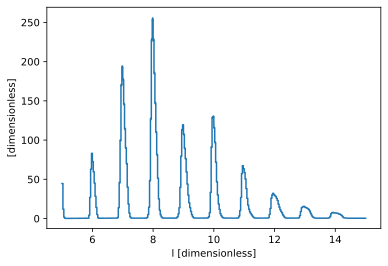

In [52]:
bin_h = sc.linspace(dim='h', start =-14,stop=-5,num=181,endpoint=True)
da_q_event.hist(h=bin_h).plot()
bin_k = sc.linspace(dim='k', start =-5,stop=8,num=341,endpoint=True)
da_q_event.hist(k=bin_k).plot()
bin_l = sc.linspace(dim='l', start =5,stop=15,num=341,endpoint=True)
da_q_event.hist(l=bin_l).plot()

In [53]:
da_q_event.coords["h"] = da_q_event.coords["h"].copy()
da_q_event.coords["k"] = da_q_event.coords["k"].copy()
da_q_event.coords["l"] = da_q_event.coords["l"].copy()
da_q_event.coords["h_reduced"] = da_q_event.coords["h_reduced"].copy()
da_q_event.coords["k_reduced"] = da_q_event.coords["k_reduced"].copy()
da_q_event.coords["l_reduced"] = da_q_event.coords["l_reduced"].copy()

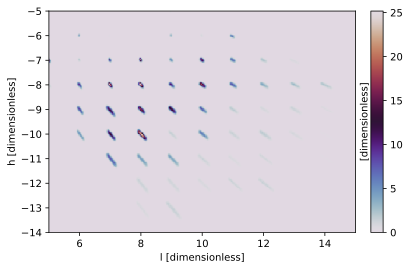

In [55]:
da_q_event.hist(h=bin_h, k=bin_k).plot(cmap='twilight')# norm="log"
da_q_event.hist(k=bin_k, l=bin_l).plot(cmap='twilight')# norm="log"
da_q_event.hist(h=bin_h, l=bin_l).plot(cmap='twilight')# norm="log"

In [56]:
bin_h_reduced = sc.linspace(dim='h_reduced', start =0.0,stop=1.0,num=101,endpoint=True)
bin_k_reduced = sc.linspace(dim='k_reduced', start =0.0,stop=1.0,num=101,endpoint=True)
bin_l_reduced = sc.linspace(dim='l_reduced', start =0.0,stop=1.0,num=101,endpoint=True)

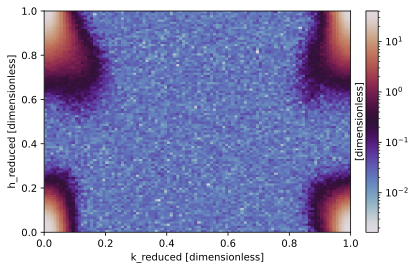

In [57]:
da_q_event.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(norm="log", cmap='twilight')

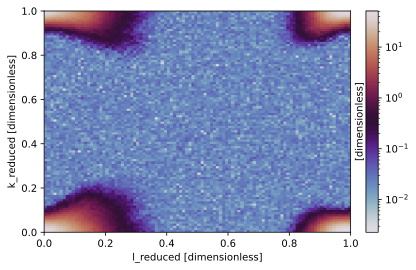

In [58]:
da_q_event.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(norm="log", cmap='twilight')

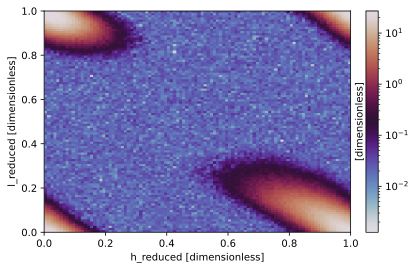

In [59]:
da_q_event.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(norm="log", cmap='twilight')

In [77]:
da_q_event.coords["Q"] = sc.norm(da_q_event.coords["Q_vec"])

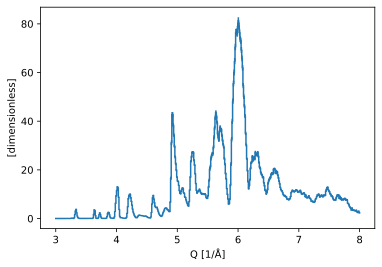

In [81]:
bin_q = sc.linspace(dim='Q', start =3,stop=8,num=501,unit="1/Angstrom",endpoint=True)
da_q_event.hist(Q=bin_q).plot()

## Correction on $\Delta t$, $\Delta L$, and sample offset
...


## Shape of the diffraction peak
...

# Peak integration
...


# Output
Export results in formats compatible with refinement tools
## EasyDiffraction
...
## FullProf 
...
## Mag2Pol
...


In [ ]:
https://scipp.github.io/user-guide/groupby.html

Probably use it for integration: asign area of detectors for indexation and integrate further

In [ ]:

hist_3d = da.hist(h=1000, k=1000, l=1000)

In [ ]:
hist_3d.data

In [78]:
graph.beamline._NO_SCATTER_GRAPH_BEAMLINE


{'Ltotal': <function scippneutron.conversion.beamline.total_straight_beam_length_no_scatter(*, source_position: scipp._scipp.core.Variable | scipp._scipp.core.DataArray | scipp._scipp.core.Dataset | scipp.core.data_group.DataGroup[typing.Any], position: scipp._scipp.core.Variable | scipp._scipp.core.DataArray | scipp._scipp.core.Dataset | scipp.core.data_group.DataGroup[typing.Any]) -> scipp._scipp.core.Variable | scipp._scipp.core.DataArray | scipp._scipp.core.Dataset | scipp.core.data_group.DataGroup[typing.Any]>}

In [ ]:
def get_da_one_hkl(da, hkl, delta_hkl):
    flag_h = sc.logical_and(da.coords['h'] > hkl[0]-delta_hkl[0] ,da.coords['h'] < hkl[0]+delta_hkl[0])
    flag_k = sc.logical_and(da.coords['k'] > hkl[1]-delta_hkl[1] ,da.coords['k'] < hkl[1]+delta_hkl[1])
    flag_l = sc.logical_and(da.coords['l'] > hkl[2]-delta_hkl[2] ,da.coords['l'] < hkl[2]+delta_hkl[2])
    event_mask = (sc.logical_and(flag_h, sc.logical_and(flag_k, flag_l))).values

    da_one_hkl = sc.DataArray(
        data=sc.array(
            dims=['event'], values=da.data.values[event_mask], variances=da.data.variances[event_mask]),
        coords={
            'Qx': sc.array(dims=['event'], values=da.coords['Qx'].values[event_mask], unit=da.coords['Qx'].unit),
            'Qy': sc.array(dims=['event'], values=da.coords['Qy'].values[event_mask], unit=da.coords['Qy'].unit),
            'Qz': sc.array(dims=['event'], values=da.coords['Qz'].values[event_mask], unit=da.coords['Qz'].unit),
            'h': sc.array(dims=['event'], values=da.coords['h'].values[event_mask], unit=da.coords['h'].unit),
            'k': sc.array(dims=['event'], values=da.coords['k'].values[event_mask], unit=da.coords['k'].unit),
            'l': sc.array(dims=['event'], values=da.coords['l'].values[event_mask], unit=da.coords['l'].unit),
            'tth': sc.array(dims=['event'], values=da.coords['tth'].values[event_mask], unit=da.coords['tth'].unit),
            'wavelength': sc.array(dims=['event'], values=da.coords['wavelength'].values[event_mask], unit=da.coords['wavelength'].unit),
        }
    )
    return da_one_hkl


In [ ]:
def load_fsq(f_name:str):
    with open(f_name, 'r') as fid:
        l_content = fid.readlines()
    l_content = [hh for hh in l_content if not hh.startswith("#")]
    l_hkl, l_fsq = [], []
    for line in l_content:
        l_hh = line.strip().split()
        l_hkl.append((int(l_hh[0]), int(l_hh[1]), int(l_hh[2])))
        l_fsq.append(l_hh[-1])
    np_hkl = numpy.array(l_hkl, dtype=int).transpose()
    np_fsq = numpy.array(l_fsq, dtype = float)
    return np_hkl, np_fsq


In [ ]:
f_name_hkl = "C60_tetra.hkl"
np_hkl, np_fsq = load_fsq(f_name_hkl)


In [ ]:
with h5py.File(f_nexus) as fid:
    l_monitor_intensity = fid["entry1"]["data"]["l_monitor_sample_txt"]["data"][()]
    l_monitor_wavelength = fid["entry1"]["data"]["l_monitor_sample_txt"]["Wavelength__AA_"][()]
func_spectra = scipy.interpolate.interp1d(l_monitor_wavelength, l_monitor_intensity)


In [ ]:
h_min = int(da.coords["h"].min().value+1)
h_max = int(da.coords["h"].max().value-1)
k_min = int(da.coords["k"].min().value+1)
k_max = int(da.coords["k"].max().value-1)
l_min = int(da.coords["l"].min().value+1)
l_max = int(da.coords["l"].max().value-1)

delta_hkl = [0.20, 0.15, 0.25]
for h in range(h_min, h_max+1):
    for k in range(k_min, k_max+1):
        for l in range(l_min, l_max+1):
            hkl = numpy.array([h,k,l], dtype=int)
            da_one_hkl = get_da_one_hkl(da, hkl, delta_hkl)
            if da_one_hkl.data.values.shape[0] < 1000:
                continue

            wavelength = sc.mean(da_one_hkl.coords['wavelength']).value
            coeff = func_spectra(wavelength) / 1e8
            tth = numpy.radians(sc.mean(da_one_hkl.coords['tth']).value)
            sin_sq = numpy.square(numpy.sin(0.5*tth))
            val = sc.sum(da_one_hkl.data)
            iint = val.value
            siint = numpy.sqrt(val.variance)
            fsq_exp = iint * sin_sq / (numpy.power(wavelength,4) * coeff)
            flag_h = np_hkl[0] == hkl[0]
            flag_k = np_hkl[1] == hkl[1]
            flag_l = np_hkl[2] == hkl[2]
            flag_hkl = numpy.logical_and(flag_h, numpy.logical_and(flag_k, flag_l))
            fsq_mod = np_fsq[flag_hkl][0]
            print(f"{hkl[0]:3} {hkl[1]:3} {hkl[2]:3} {iint:7.2f} {fsq_exp:7.2f} {fsq_mod:7.2f}  {fsq_exp/fsq_mod:7.2f}")
            # print(f"{hkl[0]:3} {hkl[1]:3} {hkl[2]:3} {iint:7.2f} {fsq_exp:7.2f}")




In [ ]:
# Synthetic example with 3 peaks
rng = numpy.random.default_rng(0)

centers = numpy.array([
    [0.2, 0.1, 0.0],
    [0.8, -0.2, 0.3],
    [-0.4, 0.5, -0.1]
])

q_events = []
weights = []

for c in centers:
    pts = c + 0.03 * rng.standard_normal((800, 3))
    q_events.append(pts)
    weights.append(rng.uniform(0.5, 1.5, size=800))

q_events = numpy.vstack(q_events)
weights = numpy.concatenate(weights)

peaks, intensities = find_multiple_peaks(q_events, weights, max_peaks=3)

print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)


Detected peaks:
 [[-0.40223781  0.50135126 -0.09777805]
 [ 0.19728945  0.10152996 -0.00128652]
 [ 0.79953506 -0.19851627  0.30079823]]
Intensities:
 [795.38879818 794.77672387 780.81633989]


In [ ]:
Detected peaks:
 [[-0.40223781  0.50135126 -0.09777805]
 [ 0.19728945  0.10152996 -0.00128652]]
Intensities:
 [795.38879818 794.77672387]

In [60]:
import numpy as np
from scipy.spatial import KDTree

def reduce_kspace_events(
    k_points,
    weights,
    target_count=None,
    distance_threshold=None,
):
    """
    Reduce weighted events in k-space by parallel merging of nearest neighbors.

    Parameters
    ----------
    k_points : (N, d) array
        Event coordinates in k-space.
    weights : (N,) array
        Event weights.
    target_count : int or None
        Stop when number of events <= target_count.
    distance_threshold : float or None
        Stop when all nearest-neighbor distances exceed this value.

    Returns
    -------
    k_points : (M, d) array
        Reduced coordinates.
    weights : (M,) array
        Reduced weights.
    """

    k_list = [np.array(k) for k in k_points]
    w_list = [float(w) for w in weights]

    while True:

        N = len(k_list)
        if target_count is not None and N <= target_count:
            break

        # Build KDTree
        tree = KDTree(np.vstack(k_list))

        # Query nearest neighbor for each point
        dists, idxs = tree.query(np.vstack(k_list), k=2)
        nn_dist = dists[:, 1]
        nn_idx = idxs[:, 1]

        # Check distance threshold stopping condition
        if distance_threshold is not None:
            if np.all(nn_dist > distance_threshold):
                break

        # Build list of candidate pairs (i, j, dist)
        pairs = [(i, nn_idx[i], nn_dist[i]) for i in range(N)]
        # Sort by distance
        pairs.sort(key=lambda x: x[2])

        merged = set()
        new_k = []
        new_w = []

        # Parallel merging: take smallest non-overlapping pairs
        for i, j, d in pairs:
            if i in merged or j in merged:
                continue
            if distance_threshold is not None and d > distance_threshold:
                break

            # Merge i and j
            wi, wj = w_list[i], w_list[j]
            ki, kj = k_list[i], k_list[j]

            w_new = wi + wj
            k_new = (wi * ki + wj * kj) / w_new

            new_k.append(k_new)
            new_w.append(w_new)

            merged.add(i)
            merged.add(j)

        # Add all unmerged points
        for idx in range(N):
            if idx not in merged:
                new_k.append(k_list[idx])
                new_w.append(w_list[idx])

        k_list = new_k
        w_list = new_w

        # If no merges happened, stop
        if len(merged) == 0:
            break

    return np.vstack(k_list), np.array(w_list)




In [82]:

# Example: 2000 events in 3D
N = 2000000
k = np.random.randn(N, 1)
w = np.random.rand(N)

k_red, w_red = reduce_kspace_events(
    k, w,
    target_count=300,
    distance_threshold=0.05
)

print(k_red.shape, w_red.shape)

(251, 1) (251,)


In [69]:
k_red.min(), k_red.max()

(np.float64(-5.00290179287727), np.float64(4.846386584872402))

	◦ max_seeds: e.g. 10^3–10^4 seeds instead of all events.
	◦ radius_factor: trade off accuracy vs speed (smaller → fewer neighbors).
	◦ Region cuts in Q before building the tree.

In [65]:
k_red, w_red = reduce_kspace_events(
    k_red, w_red,
    target_count=300,
    distance_threshold=0.05
)

print(k_red.shape, w_red.shape)

(311945, 3) (311945,)


In [42]:
peaks, intensities = find_multiple_peaks_accel(np_qxyz, np_weight, max_peaks=30)
print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)

Detected peaks:
 [[-3.92649271e+00  2.61808567e+00  3.05391068e+00]
 [-3.97110164e+00  4.79660476e-04  3.53034168e+00]
 [-4.39486743e+00  2.41258324e-04  4.39557838e+00]
 [-4.38585199e+00  4.38897385e-01  3.06934795e+00]
 [-4.38452034e+00 -4.38029663e-01  3.06866515e+00]
 [-4.39194116e+00 -4.38768797e-01  3.51312464e+00]
 [-4.39168354e+00  4.39483301e-01  3.51356598e+00]
 [-4.38859356e+00 -8.77528731e-01  3.51109226e+00]
 [-4.38843969e+00  8.78115136e-01  3.51094926e+00]
 [-3.96448840e+00  1.32177857e+00  3.96448869e+00]
 [-3.96550127e+00 -1.32140118e+00  3.96529143e+00]
 [-3.54442261e+00  1.39416088e-04  3.54473649e+00]
 [-4.39274170e+00  1.76778195e-04  3.51325422e+00]
 [-3.11342029e+00  1.78627389e-04  3.55759324e+00]
 [-3.54266384e+00  4.43187977e-01  3.09994620e+00]
 [-3.54291908e+00 -4.42564082e-01  3.09960669e+00]
 [-4.80311866e+00  3.20603467e-04  3.49490500e+00]
 [-3.09810286e+00  1.32813440e+00  2.21277236e+00]
 [-3.96263702e+00 -1.32036002e+00  3.52271887e+00]
 [-3.96205846e

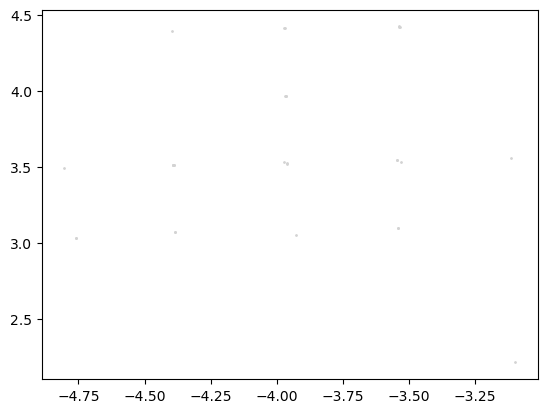

In [46]:
plt.scatter(peaks[:,0], peaks[:,2], c='lightgray', s=1)

In [10]:
peaks, intensities = find_multiple_peaks_accel(q_events, weights, max_peaks=30)
print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)

Detected peaks:
 [[ 0.20109419  0.09980372 -0.00090226]
 [-0.40025366  0.50068042 -0.09322717]
 [ 0.79967547 -0.19597578  0.29811773]
 [ 0.08829284  0.1064487  -0.00118832]
 [ 0.19241934 -0.01698265  0.01389991]]
Intensities:
 [792.558763   789.6895065  779.16661865 236.84327519 128.0564421 ]
